# recs_012_task_A — Task A training rows + two-tower grid (TensorFlow)

Same **2×2 tower grid** as `recs_012_two_tower_training_rows_explore.ipynb`, but **training labels match Task A eval**:

- **Query** = a review in the **train** split.
- **Positives** = other **train** thumbs-up apps for that user (exclude query app) — same semantics as `eval_examples.parquet` / `recs_job_eval_retrieval`.

**Not causal:** no “future liked apps after anchor.”

## Flow

1. **Train / val loss:** `prepare_eval_inputs(split="train"|"val")` → contrastive rows → `model.fit` (early stopping on val loss only).
2. **Benchmark:** score on cached **`artifacts/recs/eval_cache/val_dev_12k_v1/eval_examples.parquet`** (identical contract to the central job).

Compare results to `recs_012` (causal training) and **USE_baseline** on the same parquet.


In [ ]:
from __future__ import annotations

import json
from dataclasses import dataclass, field
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from steam_review_ml.data.loaders import (
    NORMALIZED_SPLIT_FILENAMES,
    SPLIT_TRAIN,
    SPLIT_VAL,
    load_normalized_split_df,
    resolve_normalized_split_parquet,
)
from steam_review_ml.evaluation.retrieval_offline_eval import (
    MASKING_POLICY_VERSION,
    RETRIEVAL_METRIC_COLS,
    USER_COL,
    _embedding_model_snapshot,
    _per_example_retrieval_ranking,
    _table_by_slice_for_metrics,
    _table_by_support_for_metrics,
    hit_rate_at_k,
    precision_at_k,
    prepare_eval_inputs,
    prepare_eval_inputs_from_cache,
    recall_at_k,
)
from steam_review_ml.recommender.math_utils import l2_normalize
from steam_review_ml.recommender.retrieve import ContentRetriever

UserMode = Literal["frozen", "updated"]
ItemMode = Literal["frozen_recs002", "updated_profile200"]
TrainingMode = Literal["smoke", "full"]


@dataclass(frozen=True)
class TowerSpec:
    user_mode: UserMode
    item_mode: ItemMode

    @property
    def label(self) -> str:
        return f"{self.user_mode}_user__{self.item_mode}_item"


FULL_TOWER_GRID: tuple[TowerSpec, ...] = (
    TowerSpec("frozen", "frozen_recs002"),
    TowerSpec("frozen", "updated_profile200"),
    TowerSpec("updated", "frozen_recs002"),
    TowerSpec("updated", "updated_profile200"),
)


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for parent_dir in (here, *here.parents):
        if (parent_dir / "pyproject.toml").is_file():
            return parent_dir
    raise RuntimeError(f"No pyproject.toml above {here}")


@dataclass
class Recs012TaskAConfig:
    """Task A-aligned training + eval (see recs_012_two_tower_training_rows_explore.ipynb for causal variant)."""

    repo_root: Path = field(default_factory=lambda: find_repo_root())
    min_review_chars: int = 30
    random_seed: int = 2026
    game_profile_reviews_relative: str = (
        "artifacts/recs/embeddings/game_profile/default/game_profile_reviews.parquet"
    )
    max_profile_reviews_per_game: int = 200
    profile_embed_batch_size: int = 128
    cohort_sizing_json_relative: str = "configs/recs_job_build_eval_examples.json"
    # --- tower training (2x2 grid) ---
    training_mode: TrainingMode = "full"
    tower_grid_to_run: tuple[tuple[UserMode, ItemMode], ...] = (
        ("frozen", "frozen_recs002"),
        ("frozen", "updated_profile200"),
        ("updated", "frozen_recs002"),
        ("updated", "updated_profile200"),
    )
    max_train_examples: int = 200_000
    max_val_examples: int = 2_000
    batch_size: int = 64
    proj_dim: int = 64
    temperature: float = 0.07
    epochs: int = 15
    smoke_epochs: int = 5
    early_stopping_patience: int = 3
    tower_seed: int = 2026
    adam_lr: float = 1e-3
    # updated user_mode always sets Hub trainable=True (see train_tower_spec). No separate flag.
    # --- Task A retrieval eval (post-training; not val_loss) ---
    k_retrieval: int = 100  # match configs/recs_job_eval_retrieval.json (eval contract v2)
    k_final: int = 10  # ranking depth for _per_example_retrieval_ranking (retrieval metrics use k_retrieval)
    eval_examples_parquet_relative: str = (
        "artifacts/recs/eval_cache/val_dev_12k_v1/eval_examples.parquet"
    )
    max_task_a_examples_eval: int | None = None  # None = all examples in parquet
    catalog_item_batch: int = 256
    mask_anchor_app_in_scores: bool = True

    @property
    def train_parquet(self) -> Path:
        return self.repo_root / "data" / "processed" / NORMALIZED_SPLIT_FILENAMES["train"]

    @property
    def game_profile_reviews_parquet(self) -> Path:
        return self.repo_root / Path(self.game_profile_reviews_relative)

    @property
    def eval_examples_parquet(self) -> Path:
        return self.repo_root / Path(self.eval_examples_parquet_relative)

    def resolve_tower_specs(self) -> tuple[TowerSpec, ...]:
        return tuple(TowerSpec(user_mode=user_mode, item_mode=item_mode) for user_mode, item_mode in self.tower_grid_to_run)




def load_cohort_sizing(cfg: Recs012TaskAConfig) -> dict[tuple[str, str], float]:
    path = cfg.repo_root / Path(cfg.cohort_sizing_json_relative)
    raw = json.loads(path.read_text(encoding="utf-8"))["cohort_sizing"]
    out: dict[tuple[str, str], float] = {}
    for key, pct in raw.items():
        left, right = key.split("|", 1)
        out[(left.strip(), right.strip())] = float(pct)
    return out


CFG = Recs012TaskAConfig(
    training_mode="full",
    tower_grid_to_run=(
        ("frozen", "frozen_recs002"),
        ("frozen", "updated_profile200"),
        ("updated", "frozen_recs002"),
        ("updated", "updated_profile200"),
    ),
)
processed_data_dir = CFG.repo_root / "data" / "processed"
val_parquet_path, val_split_resolved = resolve_normalized_split_parquet(processed_data_dir, SPLIT_VAL)
print("repo_root:", CFG.repo_root)
print("train_parquet exists:", CFG.train_parquet.is_file(), CFG.train_parquet)
print(
    "val parquet (resolved):",
    val_split_resolved,
    val_parquet_path.is_file(),
    val_parquet_path,
)
print("game_profile_reviews:", CFG.game_profile_reviews_parquet.is_file(), CFG.game_profile_reviews_parquet)
print("eval_examples_parquet:", CFG.eval_examples_parquet.is_file(), CFG.eval_examples_parquet)
_eval_job_path = CFG.repo_root / "configs" / "recs_job_eval_retrieval.json"
if _eval_job_path.is_file():
    CFG.k_retrieval = int(json.loads(_eval_job_path.read_text(encoding="utf-8"))["k_retrieval"])
print("training_mode:", CFG.training_mode)
print("tower grid:", [s.label for s in CFG.resolve_tower_specs()])
print("k_retrieval (eval contract):", CFG.k_retrieval, "from", _eval_job_path if _eval_job_path.is_file() else "default")
print("max_train_examples:", CFG.max_train_examples, "max_val_examples:", CFG.max_val_examples, "epochs:", CFG.epochs)


/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo_root: /home/ryanr/workspace/steam_recommendations
train_parquet exists: True /home/ryanr/workspace/steam_recommendations/data/processed/steam_reviews_cleaned_english_train_norm.parquet
val parquet (resolved): val True /home/ryanr/workspace/steam_recommendations/data/processed/steam_reviews_cleaned_english_val_norm.parquet
game_profile_reviews: True /home/ryanr/workspace/steam_recommendations/artifacts/recs/embeddings/game_profile/default/game_profile_reviews.parquet
eval_examples_parquet: True /home/ryanr/workspace/steam_recommendations/artifacts/recs/eval_cache/val_dev_12k_v1/eval_examples.parquet
training_mode: full
tower grid: ['frozen_user__frozen_recs002_item', 'frozen_user__updated_profile200_item', 'updated_user__frozen_recs002_item', 'updated_user__updated_profile200_item']
k_retrieval (eval contract): 100 from /home/ryanr/workspace/steam_recommendations/configs/recs_job_eval_retrieval.json
max_train_examples: 200000 max_val_examples: 2000 epochs: 15


In [2]:
def load_retriever(cfg: Recs012TaskAConfig) -> ContentRetriever:
    return ContentRetriever(repo_root=cfg.repo_root)


retriever = load_retriever(CFG)
cohort_sizing = load_cohort_sizing(CFG)
print("repo_root:", CFG.repo_root)
print("tower grid:", [s.label for s in CFG.resolve_tower_specs()])

print("Building Task A train examples (split=train)...")
train_inputs = prepare_eval_inputs(
    repo_root=CFG.repo_root,
    split="train",
    active_cohort="all",
    max_examples=int(CFG.max_train_examples),
    support_app_filter_mode="strict",
    cohort_sizing=cohort_sizing,
    min_review_chars=CFG.min_review_chars,
    max_train_rows_per_user=5,
    random_seed=int(CFG.random_seed),
    verbose=True,
)
train_examples = train_inputs.examples
print("Task A train examples:", len(train_examples))

print("Building Task A val examples for val_loss (split=val)...")
val_inputs = prepare_eval_inputs(
    repo_root=CFG.repo_root,
    split="val",
    active_cohort="all",
    max_examples=int(CFG.max_val_examples),
    support_app_filter_mode="strict",
    cohort_sizing=cohort_sizing,
    min_review_chars=CFG.min_review_chars,
    max_train_rows_per_user=5,
    random_seed=int(CFG.random_seed) + 1,
    verbose=True,
)
val_examples = val_inputs.examples
print("Task A val examples (monitoring):", len(val_examples))



repo_root: /home/ryanr/workspace/steam_recommendations
tower grid: ['frozen_user__frozen_recs002_item', 'frozen_user__updated_profile200_item', 'updated_user__frozen_recs002_item', 'updated_user__updated_profile200_item']
Building Task A train examples (split=train)...
Loaded split rows: eval=3,878,131 train=3,878,131 split_used=train


build eval examples: 100%|██████████| 200000/200000 [00:04<00:00, 47780.86row/s]


Prepared evaluation inputs: records=3,335,365 sampled=200,000 evaluable_examples=132,436
Drop reasons: {'no_other_positive_app': 67564}
Task A train examples: 132436
Building Task A val examples for val_loss (split=val)...
Loaded split rows: eval=1,617,344 train=3,878,131 split_used=val


build eval examples: 100%|██████████| 2000/2000 [00:00<00:00, 44494.58row/s]


Prepared evaluation inputs: records=1,400,227 sampled=2,000 evaluable_examples=2,000
Drop reasons: {'no_other_positive_app': 0}
Task A val examples (monitoring): 2000


## Tower training (TensorFlow)

**Rows:** `prepare_eval_inputs` examples → one row per `(query review, other liked app in split)`.

**Eval:** cached `eval_examples.parquet` (Task A contract).


In [3]:
def load_hub_settings(retriever: ContentRetriever) -> tuple[str, int | None]:
    _, _, meta_path = retriever._artifact_paths()
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    return str(meta["model_name"]), meta.get("max_chars_per_review")


def clip_text(text: str, max_chars: int | None) -> str:
    cleaned = (text or "").strip()
    if max_chars is None:
        return cleaned
    return cleaned[: int(max_chars)]


def build_app_mean_use_lookup(
    profile_parquet: Path,
    retriever: ContentRetriever,
    *,
    max_chars: int | None,
    max_reviews_per_game: int,
    embed_batch_size: int,
) -> dict[int, np.ndarray]:
    """Mean-pool up to N USE(review) vectors per app, L2-normalize (recs_002-style)."""
    profile_df = pd.read_parquet(profile_parquet, columns=["app_id", "review"])
    retriever._ensure_embedder()

    app_mean: dict[int, np.ndarray] = {}
    grouped = profile_df.groupby("app_id", sort=False)["review"]
    for app_id, reviews in tqdm(grouped, desc="mean-pool profile USE per app"):
        non_empty = [
            clip_text(str(text), max_chars)
            for text in reviews.fillna("").astype(str).tolist()
            if str(text).strip()
        ]
        texts = non_empty[: int(max_reviews_per_game)]
        if not texts:
            continue

        batch_vectors: list[np.ndarray] = []
        for start in range(0, len(texts), int(embed_batch_size)):
            batch_texts = texts[start : start + int(embed_batch_size)]
            raw_batch = retriever._embed_fn(batch_texts).numpy().astype(np.float32)
            batch_vectors.append(l2_normalize_rows(raw_batch))
        vectors = np.vstack(batch_vectors)
        app_mean[int(app_id)] = l2_normalize(vectors.mean(axis=0))

    if len(app_mean) < 2:
        raise RuntimeError("Need >= 2 apps with profile reviews for mean-pooled item vectors.")
    return app_mean




def task_a_positive_app_ids(ex: dict) -> set[int]:
    raw = ex["validation_positive_app_ids"]
    if isinstance(raw, set):
        return {int(app_id) for app_id in raw}
    return {int(app_id) for app_id in list(raw)}


def build_tower_rows_from_task_a_examples(
    examples: list[dict],
    retriever: ContentRetriever,
    spec: TowerSpec,
    *,
    max_examples: int,
    max_chars: int | None,
) -> tuple:
    """One row per (example, positive app); positives = other liked apps in same split (Task A)."""
    app_to_row = catalog_app_row_map(retriever)
    user_rows: list[np.ndarray] = []
    user_texts: list[str] = []
    item_row_ids: list[int] = []
    group_ids: list[int] = []
    group_id = 0
    for ex in examples[: int(max_examples)]:
        positives = [a for a in task_a_positive_app_ids(ex) if a in app_to_row]
        if not positives:
            continue
        query_text = clip_text(str(ex["query_text"]), max_chars)
        if spec.user_mode == "frozen":
            user_embedding = np.asarray(retriever.embed_text(query_text), dtype=np.float32)
        for app_id in positives:
            if spec.user_mode == "frozen":
                user_rows.append(user_embedding)
            else:
                user_texts.append(query_text)
            item_row_ids.append(int(app_to_row[int(app_id)]))
            group_ids.append(group_id)
        group_id += 1
    if len(item_row_ids) < 2:
        raise RuntimeError(f"{spec.label}: need >= 2 rows after join.")
    item_rows = np.asarray(item_row_ids, dtype=np.int32)
    group_arr = np.asarray(group_ids, dtype=np.int32)
    if spec.user_mode == "frozen":
        return np.stack(user_rows), item_rows, group_arr
    return np.asarray(user_texts, dtype=object), item_rows, group_arr


def catalog_matrix_from_mean_lookup(
    app_ids: np.ndarray,
    app_mean_use_lookup: dict[int, np.ndarray],
    fallback_matrix: np.ndarray,
) -> np.ndarray:
    rows: list[np.ndarray] = []
    for row_index, app_id in enumerate(app_ids.tolist()):
        vector = app_mean_use_lookup.get(int(app_id))
        if vector is None:
            rows.append(np.asarray(fallback_matrix[row_index], dtype=np.float32))
        else:
            rows.append(np.asarray(vector, dtype=np.float32))
    return np.stack(rows, axis=0)


def catalog_app_row_map(retriever: ContentRetriever) -> dict[int, int]:
    return {int(app_id): row_index for row_index, app_id in enumerate(np.asarray(retriever.app_ids).tolist())}


def multi_positive_inbatch_loss(similarity_logits, group_ids):
    """`-log sum_{positives} exp(sim) / sum_{batch} exp(sim)` averaged over rows."""
    group_ids_column = tf.expand_dims(group_ids, 1)
    group_ids_row = tf.expand_dims(group_ids, 0)
    positive_mask = tf.cast(tf.equal(group_ids_column, group_ids_row), tf.float32)
    log_normalizer = tf.reduce_logsumexp(similarity_logits, axis=1)
    masked_logits = similarity_logits + (positive_mask - 1.0) * 1e9
    log_positive_sum = tf.reduce_logsumexp(masked_logits, axis=1)
    return tf.reduce_mean(-(log_positive_sum - log_normalizer))


def contrastive_loss_from_vectors(user_vectors, item_vectors, group_ids, temperature):
    user_norm = tf.math.l2_normalize(user_vectors, axis=1)
    item_norm = tf.math.l2_normalize(item_vectors, axis=1)
    logits = tf.matmul(user_norm, item_norm, transpose_b=True) / temperature
    user_to_item = multi_positive_inbatch_loss(logits, group_ids)
    item_to_user = multi_positive_inbatch_loss(tf.transpose(logits), group_ids)
    total = 0.5 * (user_to_item + item_to_user)
    return total, user_to_item, item_to_user


def make_frozen_user_dataset(user_embeddings, item_row_ids, group_ids, batch_size, shuffle_seed):
    return (
        tf.data.Dataset.from_tensor_slices(
            (
                user_embeddings.astype(np.float32),
                item_row_ids.astype(np.int32),
                group_ids.astype(np.int32),
            )
        )
        .shuffle(int(user_embeddings.shape[0]), seed=shuffle_seed)
        .batch(batch_size, drop_remainder=True)
        .map(
            lambda user_batch, item_row_batch, group_batch: {
                "user": user_batch,
                "item_row_id": item_row_batch,
                "group_id": group_batch,
            }
        )
    )


def make_updated_user_dataset(user_texts, item_row_ids, group_ids, batch_size, shuffle_seed):
    return (
        tf.data.Dataset.from_tensor_slices(
            (
                tf.constant(list(user_texts), dtype=tf.string),
                item_row_ids.astype(np.int32),
                group_ids.astype(np.int32),
            )
        )
        .shuffle(int(len(user_texts)), seed=shuffle_seed)
        .batch(batch_size, drop_remainder=True)
        .map(
            lambda user_batch, item_row_batch, group_batch: {
                "user_text": user_batch,
                "item_row_id": item_row_batch,
                "group_id": group_batch,
            }
        )
    )


def l2_normalize_rows(matrix: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    mat = np.asarray(matrix, dtype=np.float32)
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms = np.maximum(norms, eps)
    return mat / norms


def tower_fit_kwargs(cfg: Recs012TaskAConfig, n_train_rows: int, n_val_rows: int, batch_size: int) -> dict:
    if cfg.training_mode == "smoke":
        return {
            "epochs": int(cfg.smoke_epochs),
            "steps_per_epoch": 1,
            "validation_steps": 1,
        }
    steps_train = max(1, int(n_train_rows) // int(batch_size))
    steps_val = max(1, int(n_val_rows) // int(batch_size))
    return {
        "epochs": int(cfg.epochs),
        "steps_per_epoch": steps_train,
        "validation_steps": steps_val,
    }


def precompute_catalog_item_vectors(
    spec: TowerSpec,
    model,
    retriever: ContentRetriever,
    *,
    batch_size: int,
):
    app_ids = np.asarray(retriever.app_ids, dtype=np.int64)
    valid_mask_in = np.ones(app_ids.shape[0], dtype=bool)

    parts: list[np.ndarray] = []
    for start in range(0, app_ids.shape[0], batch_size):
        stop = start + batch_size
        item_row_batch = tf.constant(np.arange(start, min(stop, app_ids.shape[0])), dtype=tf.int32)
        parts.append(model.encode_item_by_row_ids(item_row_batch).numpy())
    item_vectors = np.vstack(parts).astype(np.float32, copy=False)
    return item_vectors, valid_mask_in, app_ids


def encode_anchor_user_vector(
    spec: TowerSpec,
    model,
    retriever: ContentRetriever,
    anchor_text: str,
    *,
    max_chars: int | None,
):
    if spec.user_mode == "frozen":
        frozen = np.asarray(retriever.embed_text(clip_text(anchor_text, max_chars)), dtype=np.float32)
        return model.user_projection(tf.constant(frozen[None], dtype=tf.float32)).numpy()[0]
    text_batch = tf.constant([clip_text(anchor_text, max_chars)], dtype=tf.string)
    return model.encode_user(text_batch).numpy()[0]


def score_catalog(
    user_vector: np.ndarray,
    item_vectors: np.ndarray,
    valid_mask: np.ndarray,
    *,
    mask_row: int | None,
) -> np.ndarray:
    user_unit = l2_normalize(user_vector.astype(np.float32, copy=False))
    item_unit = l2_normalize_rows(item_vectors)
    scores = item_unit @ user_unit
    scores = scores.astype(np.float64, copy=False)
    scores[~valid_mask] = -np.inf
    if mask_row is not None and 0 <= int(mask_row) < scores.shape[0]:
        scores[int(mask_row)] = -np.inf
    return scores


def retrieval_eval_slice_name(n_eval_targets: int) -> str:
    """Align with recs_011 / recommendation_evaluation_overview.md (Task A n_eval_targets)."""
    if int(n_eval_targets) >= 2:
        return "slice_a_multi_target"
    if int(n_eval_targets) == 1:
        return "slice_b_single_target"
    return "slice_c_zero_target"


def annotate_retrieval_slices(per_anchor_df: pd.DataFrame) -> pd.DataFrame:
    out = per_anchor_df.copy()
    if "slice_name" in out.columns:
        return out
    target_col = "n_eval_targets" if "n_eval_targets" in out.columns else "n_future_pos_apps"
    out["slice_name"] = out[target_col].map(lambda n: retrieval_eval_slice_name(int(n)))
    return out


def summarize_retrieval_contract(per_anchor_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = per_anchor_df.copy()
    if "label" not in df.columns and "method" in df.columns:
        df = df.rename(columns={"method": "label"})
    overall = df.groupby("label", as_index=False)[RETRIEVAL_METRIC_COLS].mean()
    by_slice = (
        df.groupby(["label", "slice_name"], as_index=False)[RETRIEVAL_METRIC_COLS]
        .mean()
        .sort_values(["slice_name", "label"])
    )
    return overall, by_slice


def print_retrieval_coverage(per_anchor_df: pd.DataFrame, *, k: int) -> None:
    eval_rows = per_anchor_df[per_anchor_df["slice_name"] != "slice_c_zero_target"]
    counts = eval_rows["slice_name"].value_counts()
    print(f"retrieval eval anchors (k_retrieval={k}):", len(eval_rows))
    for slice_name, count in counts.items():
        print(f"  {slice_name}: {int(count)}")


def pick_tower_winner_by_contract(by_slice: pd.DataFrame) -> str | None:
    """Best Recall@K on slice A among tower labels; tie-break Precision@K, Hit@K."""
    towers = by_slice[~by_slice["label"].eq("USE_baseline")]
    slice_a = towers[towers["slice_name"].eq("slice_a_multi_target")].copy()
    if slice_a.empty:
        return None
    slice_a = slice_a.sort_values(["Recall@K", "Precision@K", "Hit@K"], ascending=False)
    return str(slice_a.iloc[0]["label"])


def _task_a_examples_for_eval(eval_inputs, cfg: Recs012TaskAConfig) -> list[dict]:
    examples = list(eval_inputs.examples)
    if cfg.max_task_a_examples_eval is not None:
        examples = examples[: int(cfg.max_task_a_examples_eval)]
    return examples


def make_use_baseline_score_fn(
    retriever: ContentRetriever,
    eval_inputs,
    cfg: Recs012TaskAConfig,
    *,
    max_chars: int | None,
):
    catalog_unit = l2_normalize_rows(np.asarray(eval_inputs.embedding_matrix, dtype=np.float32))
    app_to_row = eval_inputs.app_to_row

    def score_fn(ex: dict) -> np.ndarray:
        user_unit = l2_normalize(
            np.asarray(retriever.embed_text(clip_text(str(ex["query_text"]), max_chars)), dtype=np.float32)
        )
        scores = catalog_unit @ user_unit
        scores = scores.astype(np.float64, copy=False)
        if cfg.mask_anchor_app_in_scores:
            mask_row = app_to_row.get(int(ex["query_app_id"]))
            if mask_row is not None:
                scores[int(mask_row)] = -np.inf
        return scores

    return score_fn


def make_tower_score_fn(
    spec: TowerSpec,
    model,
    retriever: ContentRetriever,
    eval_inputs,
    cfg: Recs012TaskAConfig,
    *,
    max_chars: int | None,
):
    item_vectors, valid_mask, _app_ids = precompute_catalog_item_vectors(
        spec,
        model,
        retriever,
        batch_size=int(cfg.catalog_item_batch),
    )
    app_to_row = eval_inputs.app_to_row

    def score_fn(ex: dict) -> np.ndarray:
        user_vector = encode_anchor_user_vector(
            spec,
            model,
            retriever,
            str(ex["query_text"]),
            max_chars=max_chars,
        )
        mask_row = app_to_row.get(int(ex["query_app_id"])) if cfg.mask_anchor_app_in_scores else None
        return score_catalog(user_vector, item_vectors, valid_mask, mask_row=mask_row)

    return score_fn


def run_task_a_retrieval_eval(
    *,
    label: str,
    score_fn,
    eval_inputs,
    cfg: Recs012TaskAConfig,
    retriever: ContentRetriever,
    verbose: bool = True,
) -> pd.DataFrame:
    examples = _task_a_examples_for_eval(eval_inputs, cfg)
    df_retrieval, _df_ranking, _artifacts = _per_example_retrieval_ranking(
        method_name=label,
        score_fn=score_fn,
        examples=examples,
        app_ids=eval_inputs.app_ids,
        k_retrieval=int(cfg.k_retrieval),
        k_final=int(cfg.k_final),
        masking_policy_version=MASKING_POLICY_VERSION,
        model_version=_embedding_model_snapshot(retriever),
        verbose=verbose,
    )
    return df_retrieval.rename(columns={"method": "label"})


def summarize_task_a_retrieval(per_anchor_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = annotate_retrieval_slices(per_anchor_df)
    overall, by_slice = summarize_retrieval_contract(df)
    by_support = _table_by_support_for_metrics(
        df.rename(columns={"label": "method"}),
        metric_cols=RETRIEVAL_METRIC_COLS,
        ranking=False,
    ).rename(columns={"method": "label"})
    return overall, by_slice, by_support


def train_tower_spec(
    spec: TowerSpec,
    train_payload: tuple,
    val_payload: tuple,
    cfg: Recs012TaskAConfig,
    *,
    hub_url: str,
    item_init_matrix: np.ndarray,
):
    import os

    import tensorflow as tf
    import tensorflow_hub as hub
    from tensorflow import keras

    os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
    if spec.user_mode == "updated":
        tf.config.optimizer.set_jit(False)

    batch_size = int(cfg.batch_size)
    projection_dim = int(cfg.proj_dim)
    temperature = float(cfg.temperature)
    seed = int(cfg.tower_seed)
    user_updated = spec.user_mode == "updated"
    item_updated = spec.item_mode == "updated_profile200"
    trainable_use = user_updated

    class TwoTowerModel(keras.Model):
        def __init__(self):
            super().__init__(name=f"tower_{spec.label}")
            if user_updated:
                self.user_encoder = hub.KerasLayer(hub_url, trainable=trainable_use, name="user_use")
            self.user_projection = keras.layers.Dense(projection_dim)
            self.item_projection = keras.layers.Dense(projection_dim)
            self.item_base = self.add_weight(
                name="item_base_embeddings",
                shape=item_init_matrix.shape,
                initializer=keras.initializers.Constant(item_init_matrix),
                trainable=item_updated,
            )

        def encode_user(self, texts):
            with tf.device("/CPU:0"):
                encoded = self.user_encoder(texts)
            return self.user_projection(encoded)

        def encode_item_by_row_ids(self, item_row_ids):
            item_base_vectors = tf.gather(self.item_base, item_row_ids)
            return self.item_projection(item_base_vectors)

        def _user_vectors(self, batch):
            if user_updated:
                return self.encode_user(batch["user_text"])
            return self.user_projection(batch["user"])

        def train_step(self, batch):
            with tf.GradientTape() as tape:
                user_vectors = self._user_vectors(batch)
                item_vectors = self.encode_item_by_row_ids(batch["item_row_id"])
                loss, u2i, i2u = contrastive_loss_from_vectors(
                    user_vectors, item_vectors, batch["group_id"], temperature
                )
            grads = tape.gradient(loss, self.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
            return {"loss": loss, "user_to_item_loss": u2i, "item_to_user_loss": i2u}

        def test_step(self, batch):
            user_vectors = self._user_vectors(batch)
            item_vectors = self.encode_item_by_row_ids(batch["item_row_id"])
            loss, u2i, i2u = contrastive_loss_from_vectors(
                user_vectors, item_vectors, batch["group_id"], temperature
            )
            return {"loss": loss, "user_to_item_loss": u2i, "item_to_user_loss": i2u}

    model = TwoTowerModel()
    if spec.user_mode == "frozen":
        train_ds = make_frozen_user_dataset(*train_payload, batch_size, seed)
        val_ds = make_frozen_user_dataset(*val_payload, batch_size, seed + 1)
    else:
        train_ds = make_updated_user_dataset(*train_payload, batch_size, seed)
        val_ds = make_updated_user_dataset(*val_payload, batch_size, seed + 1)

    train_row_count = len(train_payload[0])
    val_row_count = len(val_payload[0])
    if train_row_count < batch_size or val_row_count < batch_size:
        raise RuntimeError(
            f"{spec.label}: need >= {batch_size} train/val rows; got train={train_row_count}, val={val_row_count}."
        )

    fit_kwargs = tower_fit_kwargs(cfg, train_row_count, val_row_count, batch_size)
    print(
        f"{spec.label}: train rows={train_row_count} val rows={val_row_count} "
        f"user={spec.user_mode} item={spec.item_mode} user_encoder_trainable={trainable_use} "
        f"item_encoder_trainable={item_updated} mode={cfg.training_mode} "
        f"steps/epoch={fit_kwargs['steps_per_epoch']} val_steps={fit_kwargs['validation_steps']} "
        f"epochs={fit_kwargs['epochs']}"
    )
    callbacks = []
    if cfg.training_mode == "full":
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=int(cfg.early_stopping_patience),
                restore_best_weights=True,
            )
        )
    model.compile(
        optimizer=keras.optimizers.Adam(cfg.adam_lr),
        jit_compile=False,
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=1,
        **fit_kwargs,
    )
    return model, history


import os

import tensorflow as tf

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

hub_url, hub_max_chars = load_hub_settings(retriever)
print("Building mean-pooled USE vectors per game (updated_profile200 item modes)...")
app_mean_use_lookup = build_app_mean_use_lookup(
    CFG.game_profile_reviews_parquet,
    retriever,
    max_chars=hub_max_chars,
    max_reviews_per_game=int(CFG.max_profile_reviews_per_game),
    embed_batch_size=int(CFG.profile_embed_batch_size),
)
print("apps with mean-pooled item vectors:", len(app_mean_use_lookup))

catalog_matrix = np.asarray(retriever.embedding_matrix, dtype=np.float32)
profile200_init_matrix = catalog_matrix_from_mean_lookup(
    np.asarray(retriever.app_ids, dtype=np.int64),
    app_mean_use_lookup,
    fallback_matrix=catalog_matrix,
)

item_init_matrix_by_mode = {
    "frozen_recs002": catalog_matrix,
    "updated_profile200": profile200_init_matrix,
}


def tower_grid_summary_table(specs: tuple[TowerSpec, ...]) -> pd.DataFrame:
    item_init_source = {
        "frozen_recs002": "recs_002 catalog NPZ",
        "updated_profile200": (
            f"mean-pooled USE (≤{CFG.max_profile_reviews_per_game} reviews/game); "
            "missing profile → recs_002 fallback"
        ),
    }
    rows = [
        {
            "label": spec.label,
            "user_mode": spec.user_mode,
            "item_mode": spec.item_mode,
            "user_encoder_trainable": spec.user_mode == "updated",
            "item_encoder_trainable": spec.item_mode == "updated_profile200",
            "item_init_source": item_init_source[spec.item_mode],
        }
        for spec in specs
    ]
    return pd.DataFrame(rows)


tower_specs = CFG.resolve_tower_specs()
variant_histories: dict[str, tf.keras.callbacks.History] = {}
variant_models: dict[str, tf.keras.Model] = {}

train_example_cap = min(int(CFG.max_train_examples), len(train_examples))
val_example_cap = min(int(CFG.max_val_examples), len(val_examples))

for spec in tower_specs:
    print("\n===", spec.label, "===")
    train_payload = build_tower_rows_from_task_a_examples(
        train_examples,
        retriever,
        spec,
        max_examples=train_example_cap,
        max_chars=hub_max_chars,
    )
    val_payload = build_tower_rows_from_task_a_examples(
        val_examples,
        retriever,
        spec,
        max_examples=val_example_cap,
        max_chars=hub_max_chars,
    )
    model, history = train_tower_spec(
        spec,
        train_payload,
        val_payload,
        CFG,
        hub_url=hub_url,
        item_init_matrix=item_init_matrix_by_mode[spec.item_mode],
    )
    variant_histories[spec.label] = history
    variant_models[spec.label] = model

print("\n=== Task A retrieval eval (cached eval_examples.parquet; post-training) ===")
if not CFG.eval_examples_parquet.is_file():
    raise FileNotFoundError(
        f"Missing {CFG.eval_examples_parquet}. Run: "
        "python scripts/recs_job_build_eval_examples.py configs/recs_job_build_eval_examples.json"
    )

task_a_eval_inputs = prepare_eval_inputs_from_cache(
    repo_root=CFG.repo_root,
    split="val",
    min_review_chars=CFG.min_review_chars,
    examples_parquet=CFG.eval_examples_parquet,
    verbose=True,
)
task_a_n = len(_task_a_examples_for_eval(task_a_eval_inputs, CFG))
print(f"scoring {task_a_n:,} Task A examples (k_retrieval={CFG.k_retrieval})")

task_a_retrieval_frames: list[pd.DataFrame] = [
    run_task_a_retrieval_eval(
        label="USE_baseline",
        score_fn=make_use_baseline_score_fn(
            retriever, task_a_eval_inputs, CFG, max_chars=hub_max_chars
        ),
        eval_inputs=task_a_eval_inputs,
        cfg=CFG,
        retriever=retriever,
        verbose=True,
    )
]
for spec in tower_specs:
    task_a_retrieval_frames.append(
        run_task_a_retrieval_eval(
            label=spec.label,
            score_fn=make_tower_score_fn(
                spec,
                variant_models[spec.label],
                retriever,
                task_a_eval_inputs,
                CFG,
                max_chars=hub_max_chars,
            ),
            eval_inputs=task_a_eval_inputs,
            cfg=CFG,
            retriever=retriever,
            verbose=True,
        )
    )

task_a_retrieval_per_anchor = pd.concat(task_a_retrieval_frames, ignore_index=True)
variant_retrieval_per_anchor = task_a_retrieval_per_anchor  # alias for downstream cells

print_retrieval_coverage(task_a_retrieval_per_anchor, k=int(CFG.k_retrieval))
task_a_retrieval_overall, task_a_retrieval_by_slice, task_a_retrieval_by_support = summarize_task_a_retrieval(
    task_a_retrieval_per_anchor
)
variant_retrieval_overall = task_a_retrieval_overall
variant_retrieval_by_slice = task_a_retrieval_by_slice

print("=== Task A retrieval by slice (primary gate) ===")
display(task_a_retrieval_by_slice)

print("=== Task A retrieval by train_support_bucket ===")
display(task_a_retrieval_by_support)

print("=== Task A retrieval overall (secondary) ===")
display(task_a_retrieval_overall.sort_values("Recall@K", ascending=False))

contract_winner = pick_tower_winner_by_contract(task_a_retrieval_by_slice)
if contract_winner:
    slice_b_row = task_a_retrieval_by_slice[
        (task_a_retrieval_by_slice["label"] == contract_winner)
        & (task_a_retrieval_by_slice["slice_name"] == "slice_b_single_target")
    ]
    hit_b = float(slice_b_row["Hit@K"].iloc[0]) if len(slice_b_row) else float("nan")
    print(
        f"Contract pick (slice A primary Recall@K): {contract_winner} | "
        f"slice B Hit@K={hit_b:.4f} (check vs other cells)"
    )
else:
    print("Contract pick: no slice A examples in cohort")

last_label = tower_specs[-1].label
tower_history = variant_histories[last_label]
print(
    f"last grid cell {last_label}: epochs={len(tower_history.history['loss'])} "
    f"final train/val loss={tower_history.history['loss'][-1]:.4f} / {tower_history.history['val_loss'][-1]:.4f} "
    "(val_loss = Task A val examples; not used for contract pick)"
)


2026-05-25 15:18:36.888701: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-25 15:18:36.949165: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779736716.958669  244797 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779736716.962334  244797 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779736717.017118  244797 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Building mean-pooled USE vectors per game (updated_profile200 item modes)...


/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
I0000 00:00:1779736719.316783  244797 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:02:00.0, compute capability: 12.0
mean-pool profile USE per app: 100%|██████████| 315/315 [00:25<00:00, 12.23it/s]


apps with mean-pooled item vectors: 315

=== frozen_user__frozen_recs002_item ===
frozen_user__frozen_recs002_item: train rows=630468 val rows=2235 user=frozen item=frozen_recs002 user_encoder_trainable=False item_encoder_trainable=False mode=full steps/epoch=9851 val_steps=34 epochs=15
Epoch 1/15
9851/9851 ━━━━━━━━━━━━━━━━━━━━ 56s 5ms/step - item_to_user_loss: 4.0864 - loss: 4.0862 - user_to_item_loss: 4.0861 - val_item_to_user_loss: 4.0290 - val_loss: 4.0289 - val_user_to_item_loss: 4.0288
Epoch 2/15
9851/9851 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - item_to_user_loss: 4.0848 - loss: 4.0837 - user_to_item_loss: 4.0827 - val_item_to_user_loss: 3.9782 - val_loss: 3.9772 - val_user_to_item_loss: 3.9762
Epoch 3/15
9851/9851 ━━━━━━━━━━━━━━━━━━━━ 62s 6ms/step - item_to_user_loss: 4.0720 - loss: 4.0726 - user_to_item_loss: 4.0731 - val_item_to_user_loss: 4.0679 - val_loss: 4.0673 - val_user_to_item_loss: 4.0666
Epoch 4/15
9851/9851 ━━━━━━━━━━━━━━━━━━━━ 66s 7ms/step - item_to_user_loss: 3.9619 - 

2026-05-25 16:15:39.672587: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT64 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


...

=== Task A retrieval by train_support_bucket ===


,train_support_bucket,label,Hit@K,Precision@K,Recall@K
0,0,updated_user__updated_profile200_item,0.519040,0.005194,0.519040
1,0,frozen_user__updated_profile200_item,0.512960,0.005133,0.512960
2,0,frozen_user__frozen_recs002_item,0.490240,0.004906,0.490240
3,0,updated_user__frozen_recs002_item,0.489600,0.004899,0.489600
4,0,USE_baseline,0.437440,0.004374,0.437280
5,1,updated_user__updated_profile200_item,0.520960,0.005210,0.520960
6,1,frozen_user__updated_profile200_item,0.514880,0.005149,0.514880
7,1,frozen_user__frozen_recs002_item,0.507200,0.005072,0.507200
8,1,updated_user__frozen_recs002_item,0.501440,0.005014,0.501440
9,1,USE_baseline,0.437440,0.004374,0.437440


=== Task A retrieval overall (secondary) ===


,label,Hit@K,Precision@K,Recall@K
4,updated_user__updated_profile200_item,0.52072,0.005523,0.503248
2,frozen_user__updated_profile200_item,0.51744,0.005482,0.499715
1,frozen_user__frozen_recs002_item,0.49680,0.005242,0.479365
3,updated_user__frozen_recs002_item,0.49552,0.005226,0.477873
0,USE_baseline,0.45296,0.004801,0.434516


Contract pick (slice A primary Recall@K): updated_user__updated_profile200_item | slice B Hit@K=0.5057 (check vs other cells)
last grid cell updated_user__updated_profile200_item: epochs=7 final train/val loss=4.0627 / 4.1644 (val_loss = Task A val examples; not used for contract pick)


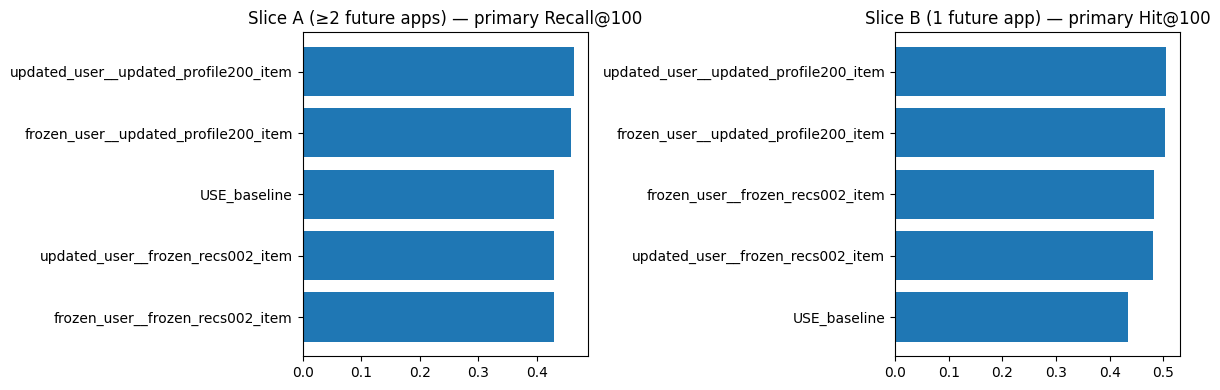

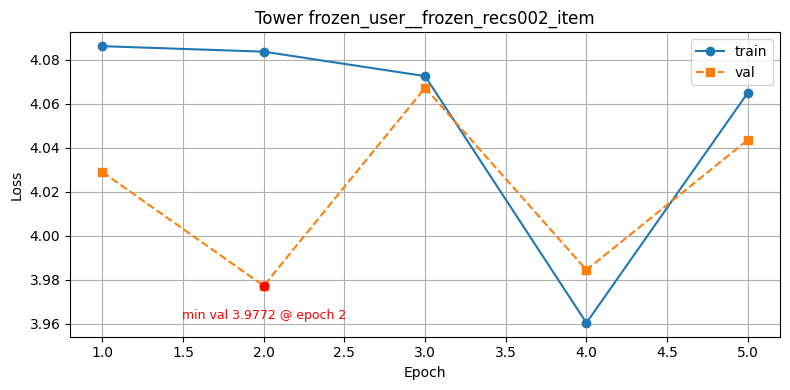

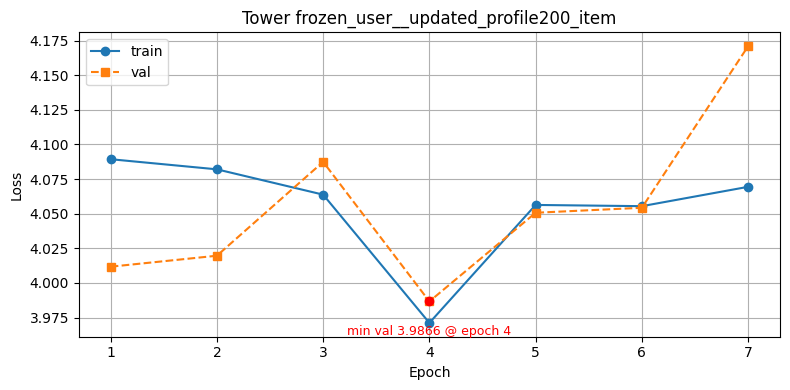

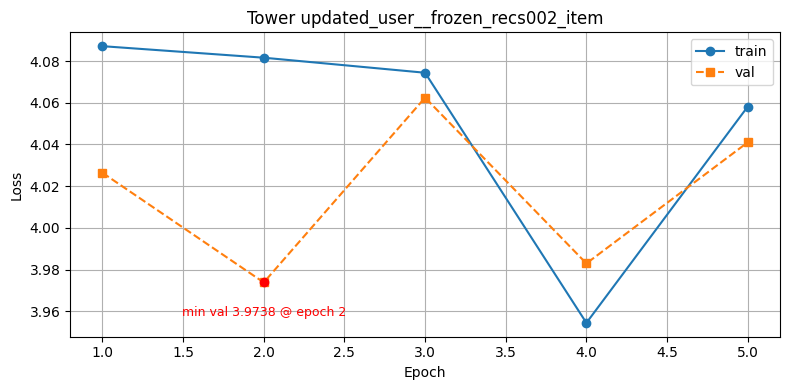

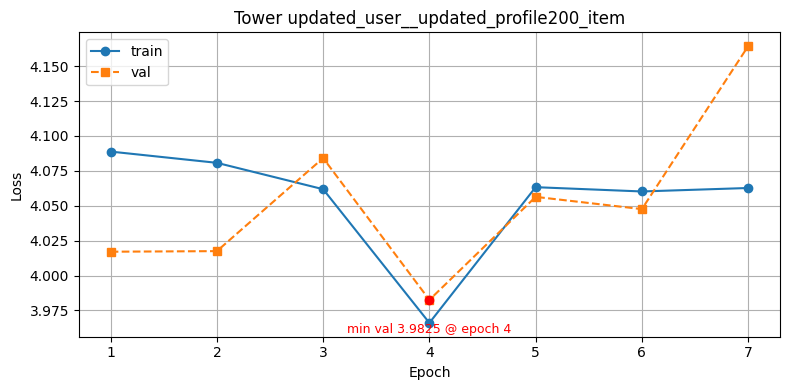

In [4]:
# Loss curves per grid cell + contract retrieval charts (slice A / B primaries)

if "variant_retrieval_by_slice" in dir():
    k = int(CFG.k_retrieval)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    slice_a = variant_retrieval_by_slice[
        variant_retrieval_by_slice["slice_name"] == "slice_a_multi_target"
    ].sort_values("Recall@K")
    slice_b = variant_retrieval_by_slice[
        variant_retrieval_by_slice["slice_name"] == "slice_b_single_target"
    ].sort_values("Hit@K")
    axes[0].barh(slice_a["label"], slice_a["Recall@K"])
    axes[0].set_title(f"Slice A (≥2 future apps) — primary Recall@{k}")
    axes[1].barh(slice_b["label"], slice_b["Hit@K"])
    axes[1].set_title(f"Slice B (1 future app) — primary Hit@{k}")
    plt.tight_layout()
    plt.show()

for label, history in variant_histories.items():
    steps = np.arange(1, len(history.history["loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(steps, history.history["loss"], marker="o", label="train")
    plt.plot(steps, history.history["val_loss"], marker="s", linestyle="--", label="val")
    val_losses = np.array(history.history["val_loss"])
    min_idx = int(np.argmin(val_losses))
    plt.scatter(steps[min_idx], val_losses[min_idx], color="red", zorder=5)
    plt.annotate(
        f"min val {val_losses[min_idx]:.4f} @ epoch {steps[min_idx]}",
        (steps[min_idx], val_losses[min_idx]),
        textcoords="offset points",
        xytext=(0, -24),
        ha="center",
        fontsize=9,
        color="red",
    )
    plt.title(f"Tower {label}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



## Task A: focus labels by `train_support_bucket`

Primary history breakdown is **`task_a_retrieval_by_support`** (from cached parquet; `n_support_train` = train reviews attached per example). Optional pivots below — run the tower + Task A eval cell first.

Hit@K by train_support_bucket (focus labels)


label,USE_baseline,frozen_user__frozen_recs002_item,frozen_user__updated_profile200_item,updated_user__frozen_recs002_item,updated_user__updated_profile200_item
train_support_bucket,,,,,
0,0.437440,0.490240,0.512960,0.489600,0.519040
1,0.437440,0.507200,0.514880,0.501440,0.520960
2-3,0.436167,0.467737,0.500415,0.468014,0.500415
4-7,0.512694,0.532020,0.549072,0.533156,0.550208


Recall@K by train_support_bucket (focus labels)


label,USE_baseline,frozen_user__frozen_recs002_item,frozen_user__updated_profile200_item,updated_user__frozen_recs002_item,updated_user__updated_profile200_item
train_support_bucket,,,,,
0,0.437280,0.490240,0.512960,0.489600,0.519040
1,0.437440,0.507200,0.514880,0.501440,0.520960
2-3,0.435936,0.467322,0.500000,0.467691,0.500000
4-7,0.425834,0.450005,0.465681,0.450012,0.468019


Delta (updated_profile200 − frozen_recs002); positive = profile200 wins:


,delta_Hit@K,delta_Recall@K
train_support_bucket,,
0,0.022720,0.022720
1,0.007680,0.007680
2-3,0.032678,0.032678
4-7,0.017052,0.015676


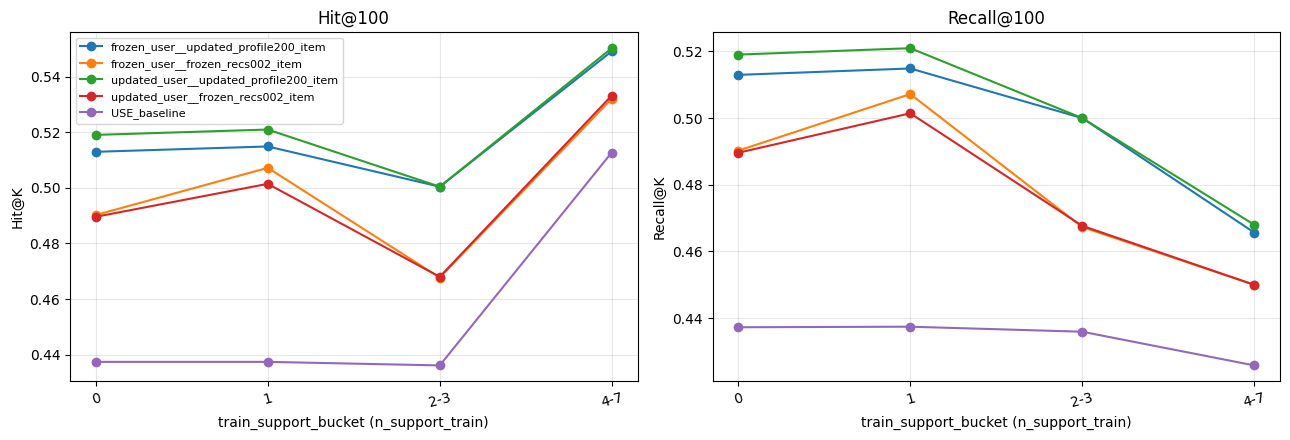

In [6]:
FOCUS_RETRIEVAL_LABELS = (
    "frozen_user__updated_profile200_item",
    "frozen_user__frozen_recs002_item",
    "updated_user__updated_profile200_item",
    "updated_user__frozen_recs002_item",
    "USE_baseline",
)

if "task_a_retrieval_by_support" not in dir():
    raise RuntimeError("Run the tower training cell (Task A eval block) first.")

focus_support = task_a_retrieval_by_support[
    task_a_retrieval_by_support["label"].isin(FOCUS_RETRIEVAL_LABELS)
].copy()
pivot_hit = focus_support.pivot(index="train_support_bucket", columns="label", values="Hit@K")
pivot_recall = focus_support.pivot(index="train_support_bucket", columns="label", values="Recall@K")

print("Hit@K by train_support_bucket (focus labels)")
display(pivot_hit)

print("Recall@K by train_support_bucket (focus labels)")
display(pivot_recall)

if (
    "frozen_user__updated_profile200_item" in pivot_hit.columns
    and "frozen_user__frozen_recs002_item" in pivot_hit.columns
):
    print("Delta (updated_profile200 − frozen_recs002); positive = profile200 wins:")
    display(
        pd.DataFrame(
            {
                "delta_Hit@K": pivot_hit["frozen_user__updated_profile200_item"]
                - pivot_hit["frozen_user__frozen_recs002_item"],
                "delta_Recall@K": pivot_recall["frozen_user__updated_profile200_item"]
                - pivot_recall["frozen_user__frozen_recs002_item"],
            }
        )
    )

k = int(CFG.k_retrieval)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, metric, title in zip(axes, ("Hit@K", "Recall@K"), (f"Hit@{k}", f"Recall@{k}")):
    for label in FOCUS_RETRIEVAL_LABELS:
        sub = focus_support.loc[focus_support["label"] == label]
        axis.plot(
            sub["train_support_bucket"].astype(str),
            sub[metric].values,
            marker="o",
            label=label,
        )
    axis.set_title(title)
    axis.set_xlabel("train_support_bucket (n_support_train)")
    axis.set_ylabel(metric)
    axis.tick_params(axis="x", rotation=15)
    axis.grid(True, alpha=0.3)
axes[0].legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()